# Laboratorio 11 — k vecinos más cercanos desde cero

k-NN es el primer método del curso que **no ajusta ningún parámetro**: el conjunto de
entrenamiento es el modelo, y toda la cuenta se hace cuando llega el punto a predecir.
Eso desplaza el problema a otro lado. Si el método se limita a mirar quién está cerca,
entonces **todo depende de qué significa cerca**, y esa es una decisión que nadie toma
por defecto.

Este laboratorio construye el algoritmo y después lo somete a tres experimentos que
atacan exactamente esa decisión:

1. **El algoritmo**: distancias, vecindario y voto, verificados contra
   `KNeighborsClassifier` de `scikit-learn`.
2. **El efecto de $k$**: la curva de error en función de $1/k$ y la elección de $k$ con
   validación cruzada.
3. **El efecto de la escala**: qué le pasa al vecindario cuando un atributo se mide en
   otras unidades, sin modificar un solo dato.
4. **El efecto de los atributos irrelevantes**: cuánto se degrada el método al agregar
   columnas que no informan, contra un modelo lineal de control.

Hay **seis ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar.

> **Notación.** La de la clase: $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n}$ el conjunto
> de entrenamiento, $\mathbf{x}_0$ el punto de consulta, $\mathcal{N}_k(\mathbf{x}_0)$ el
> conjunto de índices de los $k$ vecinos más cercanos, $d$ la distancia y $p$ la cantidad
> de atributos.

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

SEMILLA = 42

In [21]:
from pathlib import Path
import urllib.request

# Carga de datos del curso. No hace falta modificar nada.

URL_DATOS = "https://github.com/ucudal/Machine-Learning---Ingenieria-en-IA-y-CD/tree/main/data"


def ruta_del_dato(nombre: str) -> str:
    """Devuelve algo que `pd.read_csv` pueda leer, este donde este el notebook.

    Busca el archivo junto al notebook y en las carpetas `data/` de hasta tres
    niveles superiores; si no esta, usa la copia publicada en linea; y si
    tampoco hay red, en Colab ofrece subirlo a mano.
    """
    candidatas = [Path(nombre), Path("data") / nombre]
    for arriba in ("..", "../..", "../../.."):
        candidatas += [Path(arriba) / nombre, Path(arriba) / "data" / nombre]
    for ruta in candidatas:
        if ruta.exists():
            print(f"Cargado desde {ruta}")
            return str(ruta)

    url = URL_DATOS + nombre
    try:
        urllib.request.urlopen(url, timeout=15)
        print(f"No esta en disco; se descarga de {url}")
        return url
    except Exception:
        pass

    try:
        from google.colab import files  # type: ignore
    except ImportError:
        raise FileNotFoundError(
            f"No se encontro {nombre}. Dejarlo en una carpeta 'data/' junto al notebook.")

    print(f"Falta {nombre}: seleccionar el archivo para subirlo.")
    subidos = files.upload()
    destino = Path("data")
    destino.mkdir(exist_ok=True)
    ruta = destino / nombre
    ruta.write_bytes(subidos[nombre])
    return str(ruta)

### Los datos

Se leen **dos** conjuntos, uno por cada mitad del laboratorio.

| Archivo | Forma | Para qué |
|---|---|---|
| `anillos_knn.csv` | $400 \times 3$ | Dos anillos concéntricos con ruido en el plano. **Ninguna frontera lineal los separa**, de modo que sirve para ver qué gana un método que no ajusta nada |
| `vecinos_ruido.csv` | $600 \times 53$ | Dos atributos informativos, `a1` y `a2`, y **cincuenta columnas de ruido** `r01`–`r50`, independientes de la respuesta. Las columnas de ruido son anidadas: usar las dos primeras equivale a agregar dos columnas al mismo problema, no a cambiar de problema |

> **Antes de ejecutar.** Los dos archivos se descargan de webasignatura y corresponde
> dejarlos en una carpeta `data/` junto al notebook. En Colab, si el archivo no está, la
> celda de carga ofrece subirlo.

Cargado desde data/anillos_knn.csv
Cargado desde data/vecinos_ruido.csv
anillos : 400 observaciones, 2 atributos
          entrenamiento 280  (clases [140, 140])
          prueba        120  (clases [60, 60])
tabular : 600 observaciones, 52 atributos (2 informativos + 50 de ruido)


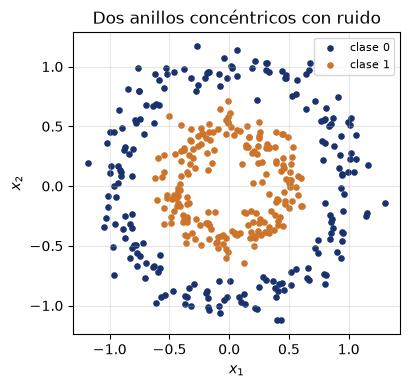

In [22]:
anillos = pd.read_csv(ruta_del_dato("anillos_knn.csv"))
tabular = pd.read_csv(ruta_del_dato("vecinos_ruido.csv"))

# --- Conjunto de los anillos: 70 / 30, como en la exposición
X_anillos = anillos[["x1", "x2"]].to_numpy(dtype=float)
y_anillos = anillos["clase"].to_numpy(dtype=int)
X_ent, X_pru, y_ent, y_pru = train_test_split(
    X_anillos, y_anillos, test_size=0.30, random_state=SEMILLA)

print(f"anillos : {X_anillos.shape[0]} observaciones, {X_anillos.shape[1]} atributos")
print(f"          entrenamiento {len(y_ent)}  (clases {np.bincount(y_ent).tolist()})")
print(f"          prueba        {len(y_pru)}  (clases {np.bincount(y_pru).tolist()})")
print(f"tabular : {tabular.shape[0]} observaciones, "
      f"{tabular.shape[1] - 1} atributos (2 informativos + 50 de ruido)")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
for clase, color in [(0, AZUL), (1, NARANJA)]:
    m = y_anillos == clase
    ax.scatter(X_anillos[m, 0], X_anillos[m, 1], s=14, c=color, label=f"clase {clase}")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Dos anillos concéntricos con ruido")
ax.legend(loc="upper right", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

---

# 1. El algoritmo, desde cero

El pseudocódigo de la clase, entero:

```text
Entrada: D = {(x_i, y_i)}_{i=1..n},  x_0,  k,  d
Salida:  ŷ(x_0)

1.  para i = 1 … n:
2.      dist[i] ← d(x_0, x_i)
3.  N ← índices de los k valores menores de dist
4.  # clasificación: ŷ ← arg max_j  (1/k) · Σ_{i∈N} I(y_i = j)
5.  # regresión:     ŷ ← (1/k) · Σ_{i∈N} y_i
6.  devolver ŷ

Costo: O(n·p + n·log k) por consulta;  O(n·p) de memoria permanente
```

Se implementa en tres piezas, una por línea del pseudocódigo: las distancias, la selección
del vecindario y el voto.

### Ejercicio 1 — Las distancias

La distancia Euclídea entre el punto de consulta y **cada** observación del conjunto:

$$
d_2(\mathbf{x}_0, \mathbf{x}_i) = \Bigl(\sum_{j=1}^{p}(x_{0j}-x_{ij})^{2}\Bigr)^{1/2}
$$

Corresponde resolverlo **sin ciclos de Python**: la resta entre una matriz $(n, p)$ y un
vector $(p,)$ se difunde fila por fila.

In [4]:
def distancias(X: np.ndarray, x0: np.ndarray) -> np.ndarray:
    return np.linalg.norm(X - x0, axis=1)

In [5]:
# VERIFICACIÓN — contra el cálculo explícito, observación por observación
x0 = X_pru[0]
propia = distancias(X_ent, x0)
lenta = np.array([np.sqrt(np.sum((fila - x0) ** 2)) for fila in X_ent])

assert propia.shape == (len(X_ent),), f"forma incorrecta: {propia.shape}"
assert np.allclose(propia, lenta)
print(f"{len(propia)} distancias calculadas   mínima {propia.min():.4f}   "
      f"máxima {propia.max():.4f}")
print("Coinciden con el cálculo explícito.")

280 distancias calculadas   mínima 0.0514   máxima 2.1566
Coinciden con el cálculo explícito.


### Ejercicio 2 — El vecindario

Los índices de los $k$ valores menores del vector de distancias, **ordenados de menor a
mayor**. Es el conjunto $\mathcal{N}_k(\mathbf{x}_0)$ del pseudocódigo.

> El orden importa acá por una razón práctica: **el ordenamiento no depende de $k$**. Los
> $k$ primeros de la lista ordenada sirven para todo $k$, y es lo que permite recorrer una
> grilla de valores sin recalcular ninguna distancia.

In [6]:
def k_vecinos(dist: np.ndarray, k: int) -> np.ndarray:
    return np.argsort(dist)[:k]

In [7]:
# VERIFICACIÓN — el vecindario está ordenado y es el de menor distancia
idx = k_vecinos(propia, 5)
assert idx.shape == (5,)
assert np.all(np.diff(propia[idx]) >= 0), "los vecinos no quedaron ordenados"
assert np.isclose(propia[idx].max(), np.sort(propia)[4]), "no son los cinco menores"

# y el ordenamiento no depende de k: los 5 primeros de los 25 son los mismos 5
assert np.array_equal(idx, k_vecinos(propia, 25)[:5])
print(f"vecinos de x_0: {idx}   distancias {propia[idx].round(4)}")
print("El vecindario de k = 5 son los cinco primeros del de k = 25.")

vecinos de x_0: [214 185  80  46 174]   distancias [0.0514 0.0943 0.0964 0.1129 0.1166]
El vecindario de k = 5 son los cinco primeros del de k = 25.


### Ejercicio 3 — El voto

La regla de clasificación: la clase mayoritaria del vecindario.

$$
\hat p_j(\mathbf{x}_0) = \frac{1}{k}\sum_{i\in\mathcal{N}_k(\mathbf{x}_0)}
\mathbb{I}(y_i = j),
\qquad
\hat y(\mathbf{x}_0) = \arg\max_j \hat p_j(\mathbf{x}_0)
$$

La función predice sobre **varios** puntos de consulta, uno por fila de `X_nuevo`. Ante un
empate se devuelve la etiqueta menor, que es la convención de `scikit-learn`: es una
decisión de implementación, no un resultado.

In [8]:
def predecir(X_ent: np.ndarray, y_ent: np.ndarray,
             X_nuevo: np.ndarray, k: int) -> np.ndarray:
    predicciones = []

    for x0 in X_nuevo:
        idx = k_vecinos(distancias(X_ent, x0), k)
        voto = np.bincount(y_ent[idx]).argmax()
        predicciones.append(voto)

    return np.asarray(predicciones, dtype=int)

In [9]:
# VERIFICACIÓN — contra KNeighborsClassifier, predicción por predicción
for k in [1, 5, 25]:
    mia = predecir(X_ent, y_ent, X_pru, k)
    sk = KNeighborsClassifier(n_neighbors=k).fit(X_ent, y_ent).predict(X_pru)
    assert np.array_equal(mia, sk), f"discrepancia con k = {k}"
    print(f"k = {k:>2}: las {len(mia)} predicciones coinciden con scikit-learn")

print("\nLa implementación propia reproduce la biblioteca.")

k =  1: las 120 predicciones coinciden con scikit-learn
k =  5: las 120 predicciones coinciden con scikit-learn
k = 25: las 120 predicciones coinciden con scikit-learn

La implementación propia reproduce la biblioteca.


---

# 2. El efecto de $k$

Con el algoritmo verificado, $k$ es la única perilla que queda. La tabla mide los dos
errores —el de entrenamiento y el de prueba— en los cuatro valores que la clase discute,
incluido el extremo $k=n$.

In [10]:
def error(y_verdadero: np.ndarray, y_predicho: np.ndarray) -> float:
    """Proporción de observaciones mal clasificadas."""
    return float(np.mean(y_verdadero != y_predicho))


n_ent = len(y_ent)
print(f"{'k':>6} {'error entren.':>15} {'error prueba':>14}  clases predichas")
for k in [1, 5, 25, n_ent]:
    e_ent = error(y_ent, predecir(X_ent, y_ent, X_ent, k))
    pred_pru = predecir(X_ent, y_ent, X_pru, k)
    print(f"{k:>6} {e_ent:15.4f} {error(y_pru, pred_pru):14.4f}"
          f"{len(np.unique(pred_pru)):>18}")

     k   error entren.   error prueba  clases predichas
     1          0.0000         0.0000                 2
     5          0.0036         0.0083                 2
    25          0.0036         0.0000                 2
   280          0.5000         0.5000                 1


### Para analizar

1. El error de entrenamiento con $k=1$ es exactamente $0$. ¿Es un resultado del método o
   una consecuencia de la definición?
2. Con $k=n$ el modelo predice una sola clase para todo el plano. ¿Qué dejó de mirar?
3. El $k$ con menor error de prueba entre los cuatro **no** es el de menor error de
   entrenamiento. ¿Qué mide cada uno de los dos errores?

**Respuesta:**

1. Con $k=1$ el error de entrenamiento es cero por la definición del método:
   cada observación de entrenamiento es su propio vecino más cercano, a distancia
   cero. No demuestra que el modelo generalice bien.

2. Con $k=n$ el vecindario contiene todo el conjunto. El modelo deja de mirar la
   posición del punto y predice siempre la clase mayoritaria global.
   
3. El error de entrenamiento mide el ajuste sobre observaciones ya vistas; el de
   prueba estima el desempeño sobre observaciones nuevas. Minimizar únicamente el
   primero favorece modelos demasiado flexibles y no garantiza el menor error de
   generalización.


### Ejercicio 4 — La curva de error

Corresponde recorrer la grilla completa de $k$ y devolver los dos errores en cada punto.
Se grafica **contra $1/k$**, que es la medida de flexibilidad del método: crece hacia la
derecha, como el grado de un polinomio.

In [11]:
def curva_error(ks: list[int]) -> tuple[np.ndarray, np.ndarray]:
    err_ent = []
    err_pru = [] 

    for k in ks:
        pred_ent = predecir(X_ent, y_ent, X_ent, k)
        pred_pru = predecir(X_ent, y_ent, X_pru, k)
        err_ent.append(error(y_ent, pred_ent))
        err_pru.append(error(y_pru, pred_pru))

    return np.asarray(err_ent), np.asarray(err_pru)

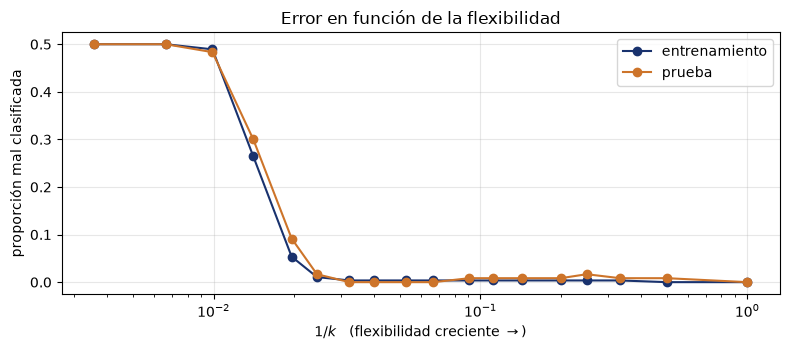

k con menor error de prueba: 1  (0.0000)
error de entrenamiento en k = 1: 0.0000


In [12]:
REJILLA = [1, 2, 3, 4, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 101, 151, n_ent]
err_ent, err_pru = curva_error(REJILLA)

inv = 1 / np.array(REJILLA, dtype=float)
fig, ax = plt.subplots()
ax.plot(inv, err_ent, "o-", color=AZUL, label="entrenamiento")
ax.plot(inv, err_pru, "o-", color=NARANJA, label="prueba")
ax.set_xscale("log")
ax.set_xlabel("$1/k$   (flexibilidad creciente $\\rightarrow$)")
ax.set_ylabel("proporción mal clasificada")
ax.set_title("Error en función de la flexibilidad")
ax.legend()
plt.tight_layout(); plt.show()

i = int(np.argmin(err_pru))
print(f"k con menor error de prueba: {REJILLA[i]}  ({err_pru[i]:.4f})")
print(f"error de entrenamiento en k = 1: {err_ent[0]:.4f}")

### DECIDE

El $k$ que minimiza el error de **prueba** acaba de quedar identificado. La celda siguiente
elige $k$ de otra manera: por validación cruzada sobre el conjunto de entrenamiento, con la
**regla del error estándar** —entre los valores cuyo error de validación cruzada queda
dentro de un error estándar del mínimo, se prefiere el más grande.

**¿Por qué no se elige el $k$ que minimiza el error de prueba, si ya se lo calculó?**

In [13]:
K_FOLDS = 10
vc = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEMILLA)
k_max = int(n_ent * (K_FOLDS - 1) / K_FOLDS)   # cada fold ajusta con menos observaciones

ks_vc, err_vc, ee_vc = [], [], []
for k in REJILLA:
    if k > k_max:
        continue
    folds = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=k), X_ent, y_ent, cv=vc)
    ks_vc.append(k)
    err_vc.append(folds.mean())
    ee_vc.append(folds.std(ddof=1) / np.sqrt(K_FOLDS))

err_vc, ee_vc = np.array(err_vc), np.array(ee_vc)
j = int(np.argmin(err_vc))
umbral = err_vc[j] + ee_vc[j]
equivalentes = [k for k, e in zip(ks_vc, err_vc) if e <= umbral]

print(f"mínimo de validación cruzada: k = {ks_vc[j]}  "
      f"(error {err_vc[j]:.4f}, EE {ee_vc[j]:.4f})")
print(f"valores dentro de un error estándar (<= {umbral:.4f}): {equivalentes}")
print(f"k elegido, el mayor del rango: {max(equivalentes)}")
print(f"su error de prueba: {err_pru[REJILLA.index(max(equivalentes))]:.4f}   "
      f"(el mejor error de prueba alcanzable era {err_pru.min():.4f})")

mínimo de validación cruzada: k = 1  (error 0.0036, EE 0.0036)
valores dentro de un error estándar (<= 0.0071): [1, 2, 3, 4, 5, 7, 9, 11, 15, 19, 25]
k elegido, el mayor del rango: 25
su error de prueba: 0.0000   (el mejor error de prueba alcanzable era 0.0000)


**Respuesta:**

No corresponde elegir $k$ usando el error de prueba porque el
conjunto de prueba debe representar datos nunca utilizados para tomar decisiones.
Si se usa para elegir $k$, deja de ser una evaluación independiente y el error
queda optimistamente sesgado. Por eso $k$ se elige mediante validación cruzada
dentro del conjunto de entrenamiento y la prueba se consulta una sola vez al final.

---

# 3. La escala decide quiénes son los vecinos

La segunda mitad del laboratorio usa el conjunto tabular: dos atributos informativos, `a1`
y `a2`, en escalas comparables. El experimento consiste en **multiplicar `a2` por 100** —el
equivalente a medirlo en centímetros en lugar de metros— y observar qué le pasa al
vecindario. **Ningún dato cambia**: cambia la unidad de una columna.

### Ejercicio 5 — Cuánto aporta cada atributo a la distancia

La distancia al cuadrado entre dos observaciones se descompone como una suma de aportes,
uno por columna. El aporte esperado de la columna $j$ es

$$
\mathbb{E}\bigl[(X_j - X'_j)^2\bigr],
$$

el promedio de $(x_{ij}-x_{lj})^2$ sobre todos los pares de observaciones. La función
devuelve esos aportes **normalizados**, de modo que sumen $1$: la fracción de la distancia
al cuadrado que aporta cada atributo.

> Corresponde calcular columna por columna. La matriz de todas las diferencias entre pares
> ocupa $n^2$ números **por atributo**: con las $52$ columnas a la vez no entra en memoria.

In [14]:
def aporte_por_atributo(X: np.ndarray) -> np.ndarray:
    aportes = 2 * np.var(X, axis=0)
    return aportes / aportes.sum()
    

In [23]:
# VERIFICACIÓN — contra la identidad E[(X_j - X'_j)^2] = 2 Var(X_j)
X_inf = tabular[["a1", "a2"]].to_numpy(dtype=float)
y_tab = tabular["clase"].to_numpy(dtype=int)

aportes = aporte_por_atributo(X_inf)
por_varianza = 2 * X_inf.var(axis=0)
por_varianza = por_varianza / por_varianza.sum()

assert np.isclose(aportes.sum(), 1.0)
assert np.allclose(aportes, por_varianza), "no coincide con 2 Var(X_j) normalizado"
print(f"aportes: {aportes.round(4)}   suma {aportes.sum():.4f}")
print("Coinciden con la identidad de la clase: el aporte de una columna es su varianza.")

aportes: [0.7919 0.2081]   suma 1.0000
Coinciden con la identidad de la clase: el aporte de una columna es su varianza.


In [24]:
FACTOR = 100
X_estirado = X_inf.copy()
X_estirado[:, 1] *= FACTOR

print(f"{'':>10} {'a1':>10} {'a2':>10}   (fracción de la distancia al cuadrado)")
for nombre, X in [("original", X_inf), ("estirado", X_estirado)]:
    a = aporte_por_atributo(X)
    print(f"{nombre:>10} {a[0] * 100:9.2f} % {a[1] * 100:9.2f} %")

                   a1         a2   (fracción de la distancia al cuadrado)
  original     79.19 %     20.81 %
  estirado      0.04 %     99.96 %


In [25]:
# El vecindario de una observación concreta, con la métrica original y con la estirada
K_VEC, i0 = 15, 0


def vecinos_de(X, i, k):
    """Los k vecinos de la observación i, sin contarla a ella misma."""
    return k_vecinos(distancias(X, X[i]), k + 1)[1:]


v_orig = set(vecinos_de(X_inf, i0, K_VEC))
v_estir = set(vecinos_de(X_estirado, i0, K_VEC))
comunes = len(v_orig & v_estir)

print(f"observación {i0}, clase verdadera {y_tab[i0]}, k = {K_VEC}")
print(f"vecinos en común: {comunes} de {K_VEC}   cambian {K_VEC - comunes}")
for nombre, vecinos in [("métrica original", v_orig), ("atributo estirado", v_estir)]:
    conteo = np.bincount(y_tab[list(vecinos)], minlength=2)
    print(f"  {nombre:>18}: voto {conteo.tolist()}  ->  clase {conteo.argmax()}")

observación 0, clase verdadera 0, k = 15
vecinos en común: 3 de 15   cambian 12
    métrica original: voto [15, 0]  ->  clase 0
   atributo estirado: voto [7, 8]  ->  clase 1


### DECIDE

El escalado corrige el problema, y **dónde se lo ajusta** no es un detalle. La celda
compara dos formas de evaluar el mismo modelo sobre el atributo estirado: sin escalar, y
con `StandardScaler` **dentro** de un pipeline.

**¿Por qué el escalador va dentro del pipeline y no aplicado al conjunto entero antes de
partir?**

In [26]:
Xe_ent, Xe_pru, ye_ent, ye_pru = train_test_split(
    X_estirado, y_tab, test_size=0.30, random_state=SEMILLA, stratify=y_tab)

sin_escalar = KNeighborsClassifier(n_neighbors=K_VEC).fit(Xe_ent, ye_ent)
con_escalar = Pipeline([("esc", StandardScaler()),
                        ("knn", KNeighborsClassifier(n_neighbors=K_VEC))]).fit(Xe_ent, ye_ent)

e_sin = 1 - sin_escalar.score(Xe_pru, ye_pru)
e_con = 1 - con_escalar.score(Xe_pru, ye_pru)
print(f"error de prueba sin escalar                  : {e_sin:.4f}")
print(f"error de prueba con StandardScaler en el pipeline: {e_con:.4f}")
print(f"el error se multiplica por {e_sin / e_con:.2f} al no escalar")

error de prueba sin escalar                  : 0.3333
error de prueba con StandardScaler en el pipeline: 0.0500
el error se multiplica por 6.67 al no escalar


**Respuesta:** 

El escalador debe quedar dentro del pipeline para que su media y su
desvío se estimen exclusivamente con el bloque de entrenamiento de cada partición.
Escalar antes de partir permitiría que las observaciones de validación o prueba
participaran en la transformación y produciría fuga de información. Además, el
pipeline garantiza que exactamente la misma transformación se aplique después a
los datos no vistos.

---

# 4. Los atributos que no informan

Un método paramétrico puede evitar una columna inútil estimando su coeficiente cerca de
cero. **k-NN no tiene coeficientes**: cada atributo entra al cómputo de la distancia con el
mismo peso. La clase lo derivó: con atributos estandarizados e independientes,

$$
\mathbb{E}\bigl[(X_j-X'_j)^2\bigr] = 2
\quad\Longrightarrow\quad
\mathbb{E}\bigl[d^2(\mathbf{x},\mathbf{x}')\bigr] = 2p,
$$

y en ningún paso de esa cuenta interviene la respuesta: **es idéntica para un atributo
informativo y para uno de ruido.**

### Ejercicio 6 — La fracción de señal

Si los $p_{\text{inf}}$ primeros atributos son los informativos, la fracción de la distancia
al cuadrado que aportan es

$$
\frac{2\,p_{\text{inf}}}{2p} = \frac{p_{\text{inf}}}{p}.
$$

La función la mide sobre datos reales, **estandarizando primero** —que es la hipótesis bajo
la que vale la cuenta— y reutilizando `aporte_por_atributo`.

In [27]:
def fraccion_senal(X: np.ndarray, p_inf: int) -> float:
    Z = StandardScaler().fit_transform(X)
    aportes = aporte_por_atributo(Z)
    return float(aportes[:p_inf].sum())

In [28]:
# VERIFICACIÓN — contra la predicción p_inf / p de la cuenta de la clase
P_INF = 2
COLUMNAS_RUIDO = [f"r{j:02d}" for j in range(1, 51)]
RUIDO = tabular[COLUMNAS_RUIDO].to_numpy(dtype=float)


def con_ruido(p_ruido: int) -> np.ndarray:
    """Los dos atributos informativos más las primeras p_ruido columnas de ruido."""
    return np.hstack([X_inf, RUIDO[:, :p_ruido]]) if p_ruido else X_inf


print(f"{'p_ruido':>8} {'p total':>8} {'medida':>10} {'p_inf/p':>10}")
for pr in [0, 2, 10, 50]:
    medida = fraccion_senal(con_ruido(pr), P_INF)
    teorica = P_INF / (P_INF + pr)
    print(f"{pr:>8} {P_INF + pr:>8} {medida:10.4f} {teorica:10.4f}")
    assert abs(medida - teorica) < 0.05, "se aparta demasiado de la cuenta teórica"

print("\nLa medición sigue a la cuenta: cada columna agregada diluye la señal.")

 p_ruido  p total     medida    p_inf/p
       0        2     1.0000     1.0000
       2        4     0.5000     0.5000
      10       12     0.1667     0.1667
      50       52     0.0385     0.0385

La medición sigue a la cuenta: cada columna agregada diluye la señal.


La degradación se mide con el protocolo completo: para cada cantidad de columnas de
ruido se **reelige $k$ por validación cruzada**, se escala dentro del pipeline y se evalúa
sobre el conjunto de prueba. Como control corre una regresión logística sobre los mismos
datos, que sí puede llevar un coeficiente a cero.

In [29]:
idx_ent, idx_pru = train_test_split(
    np.arange(len(y_tab)), test_size=0.30, random_state=SEMILLA, stratify=y_tab)
RUIDOS = [0, 1, 2, 5, 10, 20, 50]
rejilla_knn = [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51]
vc5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

filas = []
print(f"{'p_ruido':>8} {'p total':>8} {'k*':>4} {'error k-NN':>12} "
      f"{'error lineal':>14} {'señal en d²':>13}")
for pr in RUIDOS:
    X = con_ruido(pr)
    X_a, X_b = X[idx_ent], X[idx_pru]
    y_a, y_b = y_tab[idx_ent], y_tab[idx_pru]

    busqueda = GridSearchCV(
        Pipeline([("esc", StandardScaler()), ("knn", KNeighborsClassifier())]),
        {"knn__n_neighbors": rejilla_knn}, cv=vc5, n_jobs=-1).fit(X_a, y_a)
    e_knn = 1 - busqueda.score(X_b, y_b)

    lineal = Pipeline([("esc", StandardScaler()),
                       ("lr", LogisticRegression(max_iter=2000))]).fit(X_a, y_a)
    e_lin = 1 - lineal.score(X_b, y_b)

    senal = fraccion_senal(X, P_INF)
    k_star = busqueda.best_params_["knn__n_neighbors"]
    filas.append((pr, P_INF + pr, k_star, e_knn, e_lin, senal))
    print(f"{pr:>8} {P_INF + pr:>8} {k_star:>4} {e_knn:12.4f} {e_lin:14.4f} {senal:13.4f}")

deg = pd.DataFrame(filas, columns=["p_ruido", "p", "k_estrella",
                                   "error_knn", "error_lineal", "senal"])
print(f"\nk-NN  : {deg.error_knn.iloc[0]:.4f} -> {deg.error_knn.iloc[-1]:.4f}   "
      f"factor {deg.error_knn.iloc[-1] / deg.error_knn.iloc[0]:.2f}")
print(f"lineal: {deg.error_lineal.iloc[0]:.4f} -> {deg.error_lineal.iloc[-1]:.4f}   "
      f"factor {deg.error_lineal.iloc[-1] / deg.error_lineal.iloc[0]:.2f}")

 p_ruido  p total   k*   error k-NN   error lineal   señal en d²
       0        2    5       0.0500         0.0444        1.0000
       1        3    3       0.0611         0.0444        0.6667
       2        4    5       0.0833         0.0444        0.5000
       5        7    7       0.1167         0.0389        0.2857
      10       12    9       0.1500         0.0444        0.1667
      20       22   31       0.2222         0.0556        0.0909
      50       52   25       0.3000         0.0889        0.0385

k-NN  : 0.0500 -> 0.3000   factor 6.00
lineal: 0.0444 -> 0.0889   factor 2.00


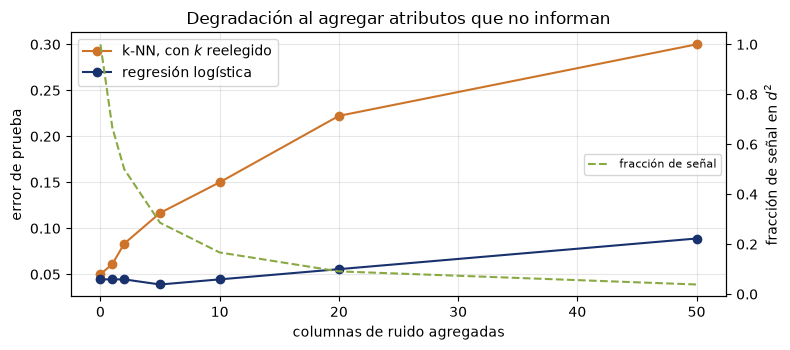

In [30]:
fig, ax = plt.subplots()
ax.plot(deg.p_ruido, deg.error_knn, "o-", color=NARANJA, label="k-NN, con $k$ reelegido")
ax.plot(deg.p_ruido, deg.error_lineal, "o-", color=AZUL, label="regresión logística")
ax.set_xlabel("columnas de ruido agregadas")
ax.set_ylabel("error de prueba")
ax.set_title("Degradación al agregar atributos que no informan")
ax.legend()

eje = ax.twinx()
eje.plot(deg.p_ruido, deg.senal, "--", color=OLIVA, label="fracción de señal")
eje.set_ylabel("fracción de señal en $d^2$")
eje.grid(False)
eje.legend(loc="center right", fontsize=8)
plt.tight_layout(); plt.show()

### Para analizar

1. Los dos métodos ven exactamente las mismas columnas. ¿Por qué uno se degrada seis veces
   y el otro dos?
2. En cada punto se reeligió $k$ por validación cruzada, y $k^\star$ trepa al agregar ruido.
   ¿Alcanza con ajustar $k$ para compensar?
3. Con dos atributos informativos, la primera columna de ruido ya mueve el error. ¿Qué dice
   eso sobre la práctica de «agregar todos los atributos disponibles y dejar que el modelo
   decida»?

**Respuesta:**

1. k-NN se degrada más porque cada columna de ruido entra directamente en la
   distancia: los puntos considerados cercanos dejan de serlo en las dimensiones
   informativas. La regresión logística estima coeficientes y puede asignar valores
   cercanos a cero a columnas inútiles, especialmente con regularización.
2. Aumentar $k$ reduce la varianza al promediar más vecinos, pero no recupera la
   noción de cercanía perdida. En los datos locales el error de k-NN pasa de
   $0.1000$ a $0.2278$, aun reeligiendo $k$.
3. Agregar todos los atributos no es una decisión neutral para un método basado en
   distancias. Conviene justificar o seleccionar variables, reducir dimensión y
   validar el efecto de cada grupo de atributos.


---

# Cierre

- **El ajuste es guardar el conjunto**, y el algoritmo entero cabe en tres piezas:
  distancias, vecindario y voto. Verificado contra `scikit-learn`, predicción por predicción.
- **$k$ es la única perilla de flexibilidad**, y se elige por validación cruzada sobre el
  conjunto de entrenamiento: el error de entrenamiento se anula en $k=1$ y no sirve, y el de
  prueba se reserva para estimar, no para elegir.
- **La escala define el vecindario.** Multiplicar una columna por $100$ cambia doce de
  quince vecinos e invierte el voto, sin modificar un solo dato.
- **Cada atributo pesa lo mismo en la distancia.** Con $50$ columnas de ruido el error de
  k-NN se multiplica por seis y el del control lineal por dos: la degradación es del método
  basado en distancia, no del problema.

## Para seguir explorando

Fuera del tiempo de clase, y sin evaluación:

1. **Ponderación por distancia.** Modificar `predecir` para que el voto use pesos
   $w_i = 1/d(\mathbf{x}_0,\mathbf{x}_i)$, con la convención para $d=0$: si hay
   coincidencias exactas, todo el peso va a ellas. Contrastar con
   `KNeighborsClassifier(weights="distance")` y medir en qué valores de $k$ ayuda.
2. **Otra métrica.** Reemplazar la distancia Euclídea por $\ell_1$ y por $\ell_\infty$ en
   `distancias`, y ver cuánto cambia el error de prueba sobre los anillos.
3. **El costo de predecir.** Medir el tiempo de `predecir` sobre los $120$ puntos de prueba
   al duplicar el conjunto de entrenamiento, y contrastarlo con el tiempo de predicción de
   la regresión logística ya ajustada.